In [74]:
%matplotlib inline

# Introduction

In this notebook, we explore two key frameworks in superconducting quantum circuits:

1. **Jaynes–Cummings model with dissipation** – This model describes a two-level system (qubit) interacting with a single quantized mode of an electromagnetic field (resonator), while accounting for energy loss mechanisms such as photon decay in the resonator and qubit relaxation or dephasing. Studying this open quantum system allows us to observe phenomena like damped Rabi oscillations and energy relaxation dynamics.

2. **Pulse-driven transmon qubit with Gaussian envelope** – In practical superconducting qubits, quantum gates are implemented using shaped microwave pulses. Here, we focus on Gaussian-shaped pulses, where the pulse amplitude and duration are tuned to achieve precise rotations of the qubit state on the Bloch sphere. This allows us to simulate realistic gate operations such as $\pi$-pulses or $\pi/2$-pulses and visualize the qubit trajectory.

For each framework, we provide a **brief theoretical overview** and a **numerical simulation**, illustrating how the system evolves over time under dissipation or controlled driving, and how the dynamics can be visualized using population plots and Bloch sphere trajectories.


# Jaynes–Cummings Model

In this section we explore the **Jaynes–Cummings model**, a fundamental description of the interaction between a two-level quantum system (qubit) and a single quantized mode of the electromagnetic field (resonator).

The main goals of this notebook are:

- Introduce the Hamiltonian of the Jaynes–Cummings model
- Show the effects of Rabi oscillations
- Include dissipation (relaxation and dephasing)
- Visualize dynamics such as the qubit population, photon number, and system energy

## 1. Theoretical Background

The total Hamiltonian of the system is:

$$
H = H_q + H_r + H_{\text{int}}
$$

where:

- Qubit Hamiltonian:
$$
H_q = -\frac{\omega_q}{2} \sigma_z \otimes I
$$

- Resonator Hamiltonian:
$$
H_r = \omega_r \, I \otimes a^\dagger a
$$

- Interaction Hamiltonian under the **Rotating Wave Approximation (RWA)**:
$$
H_{\text{int}} = g \, (\sigma_+ \otimes a + \sigma_- \otimes a^\dagger)
$$

Here:

- $\omega_q$ : qubit frequency (rad/s)  
- $\omega_r$ : resonator frequency (rad/s)  
- $g$ : coupling strength (rad/s)  
- $\sigma_+, \sigma_-$ : qubit raising and lowering operators  
- $a, a^\dagger$ : resonator annihilation and creation operators
---
<p align="center">
    <img src="jaynes_circuit.jpg" alt="Circuit diagram" width="400"/>
</p>
### Physical Interpretation

The interaction term describes the exchange of an excitation between the qubit and the cavity — one quantum of energy \( \hbar \omega_r \) is annihilated in the resonator and created in the qubit, and vice versa.

In [75]:
!pip install qutip numpy matplotlib

In [76]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import qutip as qt


In [77]:
class JaynesCummings:
    """
    Defines the Jaynes–Cummings Hamiltonian and system parameters.
    """
    def __init__(self, wq, wr, g, n_levels, kappa=0.0, gamma_relax=0.0, gamma_deph=0.0):
        self.wq = wq
        self.wr = wr
        self.g = g
        self.n_levels = n_levels
        self.kappa = kappa
        self.gamma_relax = gamma_relax
        self.gamma_deph = gamma_deph

        # Resonator operators
        self.a = qt.destroy(n_levels)
        self.adag = self.a.dag()
        self.n_r = qt.num(n_levels)

        # Qubit operators
        self.sp = qt.Qobj(np.array([[0, 0], [1, 0]]))
        self.sm = qt.Qobj(np.array([[0, 1], [0, 0]]))
        self.sz = qt.sigmaz()

        self.H = self.build_hamiltonian()

    def build_hamiltonian(self):
        H_q = -0.5 * self.wq * qt.tensor(self.sz, qt.qeye(self.n_levels))
        H_r = self.wr * qt.tensor(qt.qeye(2), self.n_r)
        H_int = self.g * (qt.tensor(self.sp, self.a) + qt.tensor(self.sm, self.adag))
        return H_q + H_r + H_int

In [78]:
class Simulation:
    """
    Executes the time evolution of the Jaynes–Cummings model.
    """
    def __init__(self, model, psi0, tlist):
        self.model = model
        self.psi0 = psi0
        self.tlist = tlist
        self.result = None

    def build_c_ops(self):
        c_ops = []
        if self.model.kappa > 0:
            c_ops.append(np.sqrt(self.model.kappa) * qt.tensor(qt.qeye(2), self.model.a))
        if self.model.gamma_relax > 0:
            c_ops.append(np.sqrt(self.model.gamma_relax) * qt.tensor(self.model.sm, qt.qeye(self.model.n_levels)))
        if self.model.gamma_deph > 0:
            c_ops.append(np.sqrt(self.model.gamma_deph) * qt.tensor(self.model.sz, qt.qeye(self.model.n_levels)))
        return c_ops

    def run(self, e_ops=None, store_states=True):
        if e_ops is None:
            qubit_proj_e = qt.tensor(self.model.sp * self.model.sm, qt.qeye(self.model.n_levels))
            resonator_n = qt.tensor(qt.qeye(2), self.model.n_r)
            energy_op = self.model.H
            e_ops = [qubit_proj_e, resonator_n, energy_op]

        c_ops = self.build_c_ops()
        self.result = qt.mesolve(self.model.H, self.psi0, self.tlist, c_ops, e_ops,
                                 options=qt.Options(store_states=store_states))
        return self.result



In [79]:
class Plotter:
    """
    Handles visualization of the simulation results.
    """
    def __init__(self, sim_result, tlist, model=None):
        self.result = sim_result
        self.tlist = tlist
        self.model = model

    def plot_oscillations_and_energy(self):
        p_excited = self.result.expect[0]
        n_photons = self.result.expect[1]
        energy = self.result.expect[2]

        t_ns = self.tlist * 1e9
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

        ax1.plot(t_ns, p_excited, label="Qubit excitation P(|e⟩)", linewidth=2)
        ax1.plot(t_ns, n_photons, '--', label="Average photon number ⟨n⟩", linewidth=2)
        ax1.set_ylabel("Expectation value")
        ax1.legend()
        ax1.grid(True, linestyle=':')
        ax1.set_ylim([-0.05, 1.05])

        ax2.plot(t_ns, energy, color='orange', label="Total energy ⟨H⟩", linewidth=1.5)
        ax2.set_xlabel("Time (ns)")
        ax2.set_ylabel("Energy [rad/s]")
        ax2.legend()
        ax2.grid(True, linestyle=':')
        plt.tight_layout()

## 2. Including Dissipation

Real quantum systems are **open systems** that interact with their environment.  
We model dissipation using the **Lindblad master equation**:

- Resonator decay:
$$
C_\kappa = \sqrt{\kappa} \, I \otimes a
$$

- Qubit relaxation:
$$
C_{\gamma_1} = \sqrt{\gamma_{\text{relax}}} \, \sigma_- \otimes I
$$

- Qubit pure dephasing:
$$
C_{\gamma_\phi} = \sqrt{\gamma_{\text{deph}}} \, \sigma_z \otimes I
$$

Where:

- $\kappa$ : resonator decay rate  
- $\gamma_{\text{relax}}$ : qubit T1 relaxation rate  
- $\gamma_{\text{deph}}$ : qubit pure dephasing rate
These terms cause the total system energy to decrease over time and the oscillations to dampen.
<p align="center">
    <img src="loss.png" alt="Circuit loss" width="400"/>
</p>

## 2. Initial state and Observables 

We typically initialize the system with the qubit in the excited state and the resonator in the vacuum:

$$
|\psi(0)\rangle = |e\rangle \otimes |0\rangle
$$

The expectation values we compute are:

1. Qubit excited-state probability:
$$
P_e = \langle \sigma_+ \sigma_- \rangle
$$

2. Average photon number in the resonator:
$$
\langle n \rangle = \langle a^\dagger a \rangle
$$

3. Total system energy:
$$
E_{\text{tot}} = \langle H \rangle
$$


C:\Users\fabio\AppData\Local\Programs\Python\Python310\lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(
C:\Users\fabio\AppData\Local\Programs\Python\Python310\lib\site-packages\qutip\solver\solver_base.py:583: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


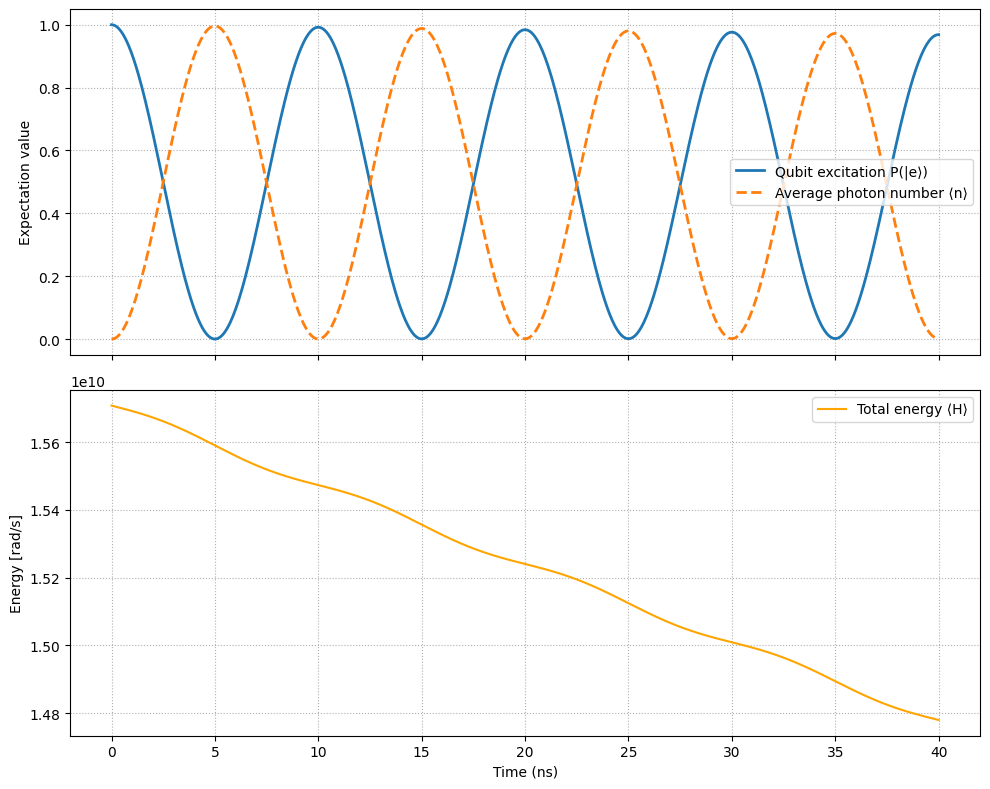

In [80]:
# Physical parameters
wq = 5.0 * 2 * np.pi * 1e9
wr = 5.0 * 2 * np.pi * 1e9
g = 0.05 * 2 * np.pi * 1e9

N = 20
t_period = np.pi / g
tlist = np.linspace(0, 4 * t_period, 1001)

# Dissipation rates
kappa = 1e6
gamma_relax = 5e5
gamma_deph = 1e5

# Build model and initial state
jc = JaynesCummings(wq, wr, g, N, kappa, gamma_relax, gamma_deph)
psi0 = qt.tensor(qt.basis(2, 1), qt.fock(N, 0))

# Run simulation
sim = Simulation(jc, psi0, tlist)
result = sim.run()

# Plot
plotter = Plotter(result, tlist, model=jc)
plotter.plot_oscillations_and_energy()

## 3. Discussion of Results

- The **Rabi oscillations** represent the periodic exchange of excitation between the qubit and the resonator.
- The **average photon number** ⟨n⟩ oscillates in antiphase with the qubit excitation probability.
- The **total energy** ⟨H⟩ decreases slowly over time due to dissipation (κ, γ₁, γφ).

If we set all dissipation rates to zero, energy is conserved and oscillations remain perfectly sinusoidal.

## 4. Conclusions

The Jaynes–Cummings model provides a clear picture of **quantum energy exchange** and forms the foundation of **quantum electrodynamics in superconducting circuits**.

In the next step (Transmon Qubit notebook), we will extend this to a **driven qubit** subject to external microwave control pulses — connecting theory to practical qubit manipulation.

# Transmon Qubit Simulation with Gaussian Pulses

In this section, we study the behavior of a **transmon qubit** under a **microwave control pulse**.  
We simulate the qubit dynamics by evolving its wavefunction in time using the Heun method (second-order Runge-Kutta).

The goal is to understand how the **pulse shape** affects the rotation of the qubit on the **Bloch Sphere** and the population probabilities of the $|0\rangle$ and $|1\rangle$ states.

Specifically, we analyze a Gaussian pulse calibrated to perform a $\pi$ rotation (X-gate) around the $x$-axis of the Bloch Sphere.

# 1. Theoretical Background

## Qubit Hamiltonian: Lab Frame vs Rotating Frame

### Lab Frame (Non-RWA)

In the **lab frame**, the Hamiltonian includes the full oscillating drive:

$$
H(t) = H_q + H_\text{drive}
$$

with

$$
H_q = -\frac{\hbar \omega_q}{2} \sigma_z,\quad
H_\text{drive}(t) = V(t) \sigma_y, \quad
V(t) = V_0 \, s(t) \sin(\omega_d t + \phi)
$$

where $s(t)$ is the pulse envelope, $V_0$ the amplitude, and $\phi$ the phase.
Here, the drive oscillates rapidly at frequency $\omega_d$, and the qubit experiences the full sinusoidal signal. This requires **fine time resolution** to capture all oscillations.

---

### Rotating Frame (RWA)

In the **rotating frame**, we transform to a frame rotating at the drive frequency $\omega_d$, which removes the fast oscillations. The Hamiltonian under the **Rotating Wave Approximation (RWA)** becomes:

$$
H_\text{RWA}(t) = -\frac{\hbar \Delta}{2} \sigma_z - \frac{\hbar \Omega(t)}{2} \big( \cos\phi \, \sigma_x + \sin\phi \, \sigma_y \big)
$$

where:

- $\Delta = \omega_q - \omega_d$ is the detuning,
- $\Omega(t) = V_0 s(t)$ is the **slowly varying Rabi frequency**.

The RWA simplifies simulation because only the **envelope** $s(t)$ drives the qubit, eliminating the need to resolve fast oscillations.

---

<p align="center">
    <img src="drive.jpg" alt="drive-circuit" width="400"/>
</p>


In [81]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import root_scalar
from mpl_toolkits.mplot3d import Axes3D

# --- Constants (Pauli Matrices) ---
SIGMA_X = np.array([[0, 1], [1, 0]], dtype=complex)
SIGMA_Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
SIGMA_Z = np.array([[1, 0], [0, -1]], dtype=complex)

## 2. Control Pulse

The pulse is defined by a **Gaussian envelope**:

$$
s(t) = \exp\Big[-\frac{(t - \mu)^2}{2\sigma^2}\Big]
$$

with center $\mu$ and width $\sigma$.  

The pulse is calibrated to produce a target rotation angle $\theta$:

$$
\theta = V_0 \int_{t_\text{start}}^{t_\text{end}} s(t) \, dt
$$

For our simulation, we aim for a $\pi$ rotation to implement an **X-gate**:

$$
\theta_\text{gate} = \pi
$$

In [82]:
class Pulse:
    """
    Represents the microwave control pulse applied to the qubit.

    This class is responsible for defining the pulse's shape (envelope),
    its carrier signal, and calibrating its parameters to achieve a
    specific quantum gate rotation.
    """

    def __init__(self, envelope_type="gaussian", V0=1.0, wd=0.0, phi=0.0, mu=0.0, sigma=1.0):
        self.envelope_type = envelope_type
        self.V0 = V0  # Drive amplitude (rad/s for RWA)
        self.wd = wd  # Drive frequency (rad/s)
        self.phi = phi
        self.mu = mu
        self.sigma = sigma

    def envelope(self, t):
        """Calculates the pulse envelope s(t) at a given time t."""
        if self.envelope_type == "gaussian":
            # Avoid division by zero if sigma is not set
            if self.sigma == 0:
                return np.zeros_like(t)
            return np.exp(-0.5 * ((t - self.mu) / self.sigma) ** 2)
        elif self.envelope_type == "rectangular":
            # Defines a rectangular pulse of duration 'sigma'
            return np.where((t >= self.mu) & (t <= self.mu + self.sigma), 1.0, 0.0)
        else:
            raise ValueError(f"Envelope type '{self.envelope_type}' not recognized.")

    def signal(self, t):
        """Calculates the full drive voltage V(t) = V0 * s(t) * sin(wd*t + phi)."""
        return self.V0 * self.envelope(t) * np.sin(self.wd * t + self.phi)

    def calibrate_for_rotation(self, theta, t_range):
        """
        Numerically finds the gaussian `sigma` required to produce a total
        pulse area corresponding to a rotation angle `theta`.
        The area is V0 * integral(envelope(t) dt).
        """
        if self.envelope_type != "gaussian":
            raise ValueError("Calibration is only implemented for Gaussian pulses.")

        t_min, t_max = t_range

        # Objective function for the solver: Area(sigma) - theta = 0
        def objective(sigma_val):
            # Temporarily set sigma to the value being tested by the solver
            self.sigma = sigma_val
            # The area is the integral of the envelope
            integral_val, _ = quad(self.envelope, t_min, t_max)
            # The total pulse area is V0 * integral
            pulse_area = self.V0 * integral_val
            return pulse_area - theta

        # Find the root of the objective function
        try:
            sol = root_scalar(objective, bracket=[1e-12, 1e-6], method='brentq')
            if not sol.converged:
                raise RuntimeError("Sigma calibration failed to converge.")
            self.sigma = sol.root
            return self.sigma
        except ValueError:
            raise RuntimeError(
                "Failed to find a valid bracket for the root solver. "
                "The target angle might be too large for the given V0 and time range."
            )

    def plot(self, tlist):
        """Plots the pulse envelope and the full drive signal."""
        s_t = self.envelope(tlist)
        V_t = self.signal(tlist)

        fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
        fig.suptitle("Control Pulse Waveforms", fontsize=14)

        ax[0].plot(tlist * 1e9, s_t, color='tab:blue', label=f"σ = {self.sigma * 1e9:.2f} ns")
        ax[0].set_ylabel("Envelope s(t)")
        ax[0].set_title(f"Envelope ({self.envelope_type.capitalize()})")
        ax[0].grid(True)
        ax[0].legend()

        ax[1].plot(tlist * 1e9, V_t, color='tab:orange')
        ax[1].set_xlabel("Time (ns)")
        ax[1].set_ylabel("Drive V(t)")
        ax[1].set_title("Full Drive Signal")
        ax[1].grid(True)

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        return fig


In [83]:
class TransmonQubit:
    """
    Represents the two-level transmon system.

    This class defines the physics of the qubit, including its natural
    frequency and how it interacts with a control pulse via its Hamiltonian.
    """

    def __init__(self, wq):
        self.wq = wq  # Qubit frequency (rad/s)

    def get_hamiltonian(self, t, pulse, rotating_frame=False):
        """Constructs the total Hamiltonian H(t) for a given pulse."""
        # Unperturbed Hamiltonian (H0)
        if not rotating_frame:
            H0 = -0.5 * self.wq * SIGMA_Z
        else:
            # In rotating frame, H0 includes the detuning
            Delta = self.wq - pulse.wd
            H0 = -0.5 * Delta * SIGMA_Z

        # Drive Hamiltonian (Hd)
        if not rotating_frame:
            # Lab frame: Hd is driven by the full oscillating signal
            Hd = pulse.signal(t) * SIGMA_Y
        else:
            # Rotating frame (RWA): Hd is driven by the slow envelope
            s = pulse.envelope(t)
            I = np.cos(pulse.phi)
            Q = np.sin(pulse.phi)
            Hd = -0.5 * pulse.V0 * s * (I * SIGMA_X + Q * SIGMA_Y)

        return H0 + Hd


## 3. Simulation Setup

The qubit is initialized in the ground state:

$$
|\psi(0)\rangle = |0\rangle = \begin{pmatrix}1\\0\end{pmatrix}
$$

The time evolution is computed over the interval $[t_\text{start}, t_\text{end}]$ using the Heun method:

$$
\frac{d}{dt}|\psi(t)\rangle = -i H(t) |\psi(t)\rangle
$$

Normalization is applied at each time step to conserve probability:

$$
\langle \psi(t) | \psi(t) \rangle = 1
$$

In [84]:
class Simulator:
    """
    Orchestrates the time-evolution simulation.

    This class takes a physical system (qubit) and a control pulse,
    and solves the Schrödinger equation to find the state of the system
    over time.
    """

    def __init__(self, qubit, pulse, rotating_frame=False):
        self.qubit = qubit
        self.pulse = pulse
        self.rotating_frame = rotating_frame

    def _schrodinger_rhs(self, t, psi):
        """Right-hand side of the Schrödinger eq: d(psi)/dt = -i * H(t) * psi."""
        H = self.qubit.get_hamiltonian(t, self.pulse, self.rotating_frame)
        return -1j * (H @ psi)

    def run(self, psi0, tlist):
        """
        Evolves the initial state `psi0` over the time steps `tlist`
        using the Heun method (a second-order Runge-Kutta method).
        """
        dt = tlist[1] - tlist[0]
        psi_history = np.zeros((len(tlist), len(psi0)), dtype=complex)
        psi_history[0] = psi0 / np.linalg.norm(psi0)  # Normalize initial state

        for i in range(len(tlist) - 1):
            psi_current = psi_history[i]
            t = tlist[i]

            # Heun's method steps
            k1 = self._schrodinger_rhs(t, psi_current)
            psi_predictor = psi_current + dt * k1
            k2 = self._schrodinger_rhs(t + dt, psi_predictor)

            psi_next = psi_current + (dt / 2.0) * (k1 + k2)

            # Normalize state at each step to conserve probability
            psi_history[i + 1] = psi_next / np.linalg.norm(psi_next)

        return SimulationResult(tlist, psi_history)



In [85]:
class SimulationResult:
    """
    Stores and visualizes the results from a simulation run.
    """

    def __init__(self, tlist, psi_history):
        self.tlist = tlist
        self.psi_history = psi_history
        self.psi_final = psi_history[-1]

    def plot_populations(self):
        """Plots the population of the |0> and |1> states over time."""
        p0 = np.abs(self.psi_history[:, 0]) ** 2
        p1 = np.abs(self.psi_history[:, 1]) ** 2

        fig = plt.figure(figsize=(8, 5))
        plt.plot(self.tlist * 1e9, p0, label="P(|0⟩)", color='tab:blue')
        plt.plot(self.tlist * 1e9, p1, label="P(|1⟩)", color='tab:red')
        plt.xlabel("Time (ns)")
        plt.ylabel("Population")
        plt.title("Qubit State Population vs. Time")
        plt.legend()
        plt.grid(True)
        plt.ylim([-0.05, 1.05])
        return fig

    def plot_bloch_trajectory(self):
        """Plots the trajectory of the state vector on the Bloch sphere."""
        # Calculate Bloch vector components for each time step
        sx = np.einsum('ij,ji->i', self.psi_history.conj(), SIGMA_X @ self.psi_history.T).real
        sy = np.einsum('ij,ji->i', self.psi_history.conj(), SIGMA_Y @ self.psi_history.T).real
        sz = np.einsum('ij,ji->i', self.psi_history.conj(), SIGMA_Z @ self.psi_history.T).real

        fig = plt.figure(figsize=(7, 7))
        ax = fig.add_subplot(111, projection='3d')

        # Draw the wireframe sphere
        u, v = np.mgrid[0:2 * np.pi:30j, 0:np.pi:30j]
        x_sphere = np.cos(u) * np.sin(v)
        y_sphere = np.sin(u) * np.sin(v)
        z_sphere = np.cos(v)
        ax.plot_wireframe(x_sphere, y_sphere, z_sphere, color='gray', alpha=0.2)

        # Plot trajectory
        ax.plot(sx, sy, sz, color='tab:purple', lw=2.5, label='Trajectory')

        # Mark start (red circle) and end (green star) points
        ax.scatter(sx[0], sy[0], sz[0], color='red', s=150, label='Start |0⟩', marker='o')
        ax.scatter(sx[-1], sy[-1], sz[-1], color='green', s=250, label='End State', marker='*')

        ax.set_xlabel("⟨σx⟩")
        ax.set_ylabel("⟨σy⟩")
        ax.set_zlabel("⟨σz⟩")
        ax.set_title("Trajectory on Bloch Sphere")
        ax.legend()
        ax.set_box_aspect([1, 1, 1])  # Aspect ratio for a perfect sphere
        return fig


## 4. Results and Discussion

We visualize:

1. **Pulse waveform**: showing both the envelope $s(t)$ and the full drive $V(t)$.
2. **Qubit populations**: probabilities $P(|0\rangle)$ and $P(|1\rangle)$ over time.
3. **Bloch sphere trajectory**: the qubit state evolution in 3D.

From the simulation, we observe:

- The Gaussian pulse successfully rotates the qubit from $|0\rangle$ to $|1\rangle$.
- Populations oscillate smoothly according to the pulse area.
- The Bloch sphere trajectory confirms a nearly perfect $\pi$ rotation along the desired axis.

These results demonstrate the importance of pulse calibration and shape in precise quantum control.


Calibrated Gaussian sigma for a π-pulse: 13.349 ns
Running simulation...
Simulation finished.
Initial state: |ψ(0)⟩ = [1.+0.j 0.+0.j]
Final state:   |ψ(t)⟩ = [-0.+0.j -1.+0.j]


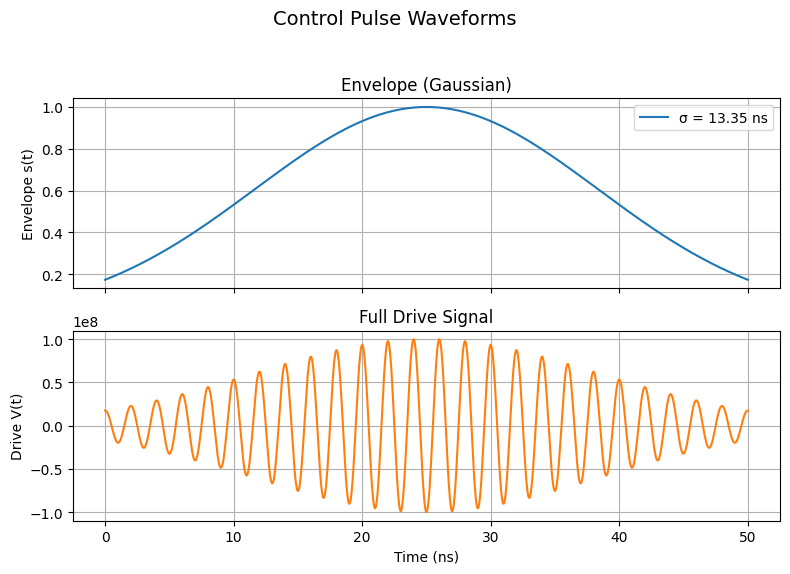

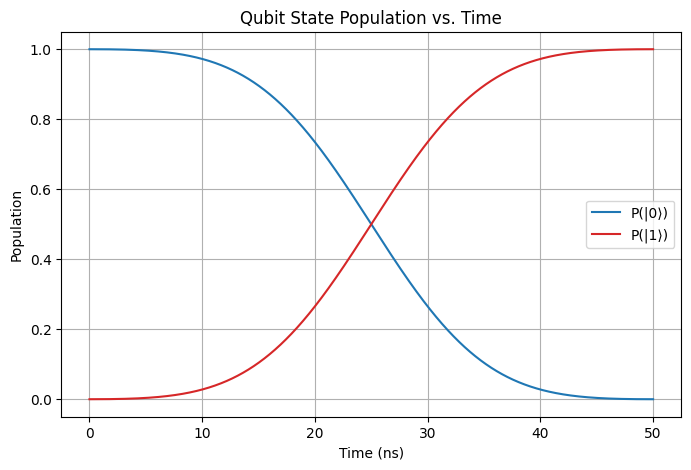

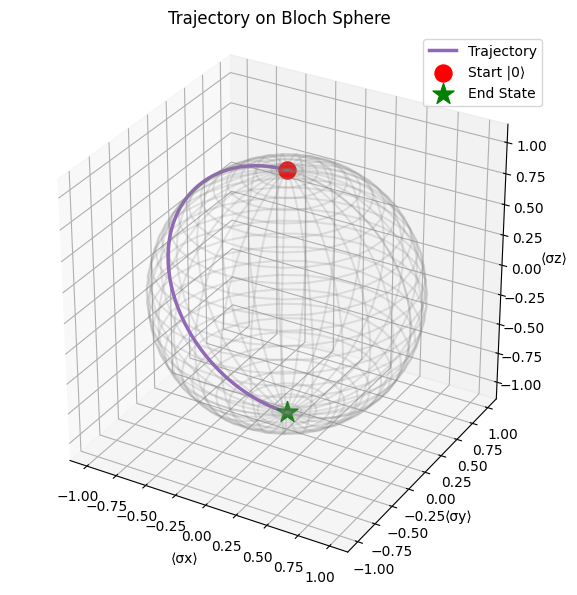

In [86]:
if __name__ == "__main__":

    # --- 1. Define Physical Parameters ---
    wq = 2 * np.pi * 5.0e8  # Qubit frequency: 500 MHz
    wd = 2 * np.pi * 5.0e8  # Drive frequency: 500 MHz (on-resonance)
    V0 = 1.0e8  # Drive amplitude (in rad/s for RWA context)
    phi = np.pi / 2  # Drive phase (pi/2 for rotation around X-axis in RWA)
    mu = 25e-9  # Center of the Gaussian pulse (25 ns)
    theta_gate = np.pi  # Target rotation angle: pi for an X-gate (NOT gate)
    t_start, t_end = 0, 50e-9  # Simulation time window

    # Time steps for the simulation
    tlist = np.linspace(t_start, t_end, 2001)

    # Initial state of the qubit: |ψ(0)⟩ = |0⟩
    psi0 = np.array([1, 0], dtype=complex)

    # --- 2. Setup the Simulation Components ---

    # Create a TransmonQubit instance
    qubit = TransmonQubit(wq=wq)

    # Create a Pulse instance (sigma is unknown for now)
    # We are simulating in the lab frame (non-RWA)
    USE_ROTATING_FRAME = True

    if USE_ROTATING_FRAME:
        # In RWA, V0 directly corresponds to Rabi frequency Omega.
        # phi=pi/2 -> sigma_y drive, which causes rotation around X-axis.
        pulse = Pulse(envelope_type="gaussian", V0=V0, wd=wd, phi=phi, mu=mu)
    else:
        # In Lab frame, V0 is a voltage amplitude.
        # We need to scale it appropriately, but for this example we keep it.
        # phi=pi/2 means the drive is a cosine.
        pulse = Pulse(envelope_type="gaussian", V0=V0, wd=wd, phi=phi, mu=mu)

    # Calibrate the pulse to achieve the desired rotation
    if pulse.envelope_type == "gaussian":
        calculated_sigma = pulse.calibrate_for_rotation(theta_gate, (t_start, t_end))
        print(f"Calibrated Gaussian sigma for a π-pulse: {calculated_sigma * 1e9:.3f} ns")
    
    # Create the Simulator instance
    simulator = Simulator(qubit, pulse, rotating_frame=USE_ROTATING_FRAME)

    # --- 3. Run the Simulation ---
    print("Running simulation...")
    results = simulator.run(psi0, tlist)
    print("Simulation finished.")
    print(f"Initial state: |ψ(0)⟩ = {np.round(results.psi_history[0], 2)}")
    print(f"Final state:   |ψ(t)⟩ = {np.round(results.psi_final, 2)}")

    # --- 4. Visualize the Results ---
    fig1 = pulse.plot(tlist)
    fig2 = results.plot_populations()
    fig3 = results.plot_bloch_trajectory()


## 5. Conclusion

- Gaussian pulses provide smooth, controlled qubit rotations.
- Accurate calibration of $\sigma$ ensures the target rotation angle $\theta_\text{gate}$.
- Visualizations of populations and Bloch sphere trajectories are consistent with theoretical predictions.

## References

1. **Gate-based Superconducting Quantum Computing**  
   Sangil Kwon, Akiyoshi Tomonaga, Gopika Lakshmi Bhai, Simon J. Devitt, Jaw-Shen Tsai

2. **QuTiP Documentation**: Lindblad Master Equation Solver.

3. **A Quantum Engineer’s Guide to Superconducting Qubits**  
   P. Krantz, M. Kjaergaard, F. Yan, T.P. Orlando, S. Gustavsson, W. D. Oliver  

4. **Notes from Qubit Electronics Course**, Politecnico di Torino